# Linear Regression

Let`s assume you have 2 points (3,4) and (2,4) and you want to use  **Linear Regression** to predict a third point but only know the x value (6,)

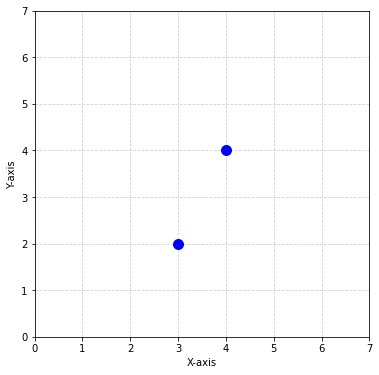

In [1]:
import matplotlib.pyplot as plt

x_i = [3, 4]
y_i = [2, 4]

# Create the plot
plt.figure(figsize=(6, 6))


plt.plot(x_i, y_i, 'bo', markersize=10, label='Two Points')


plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.xlim(0, 7)
plt.ylim(0, 7)

plt.grid(True, linestyle='--', alpha=0.6)

Now let´s remember the formula of linear regression:  **Y = a + bX**   
<br>X -> The value we already know  
<br>Y -> The value we are trying to calculate  
<br>b -> The slope  
<br>a -> The Y-intercept 

While the formula of b : **(y2-y1)/(x2-x1)**

In [2]:
def beta(x_i: list, y_i: list)-> float:
    return (y_i[1]-y_i[0])/(x_i[1]-x_i[0])

x_i=[3, 4]
y_i=[2, 4]
b=beta(x_i,y_i)
b

2.0

and how to calculate alpha ? Let´s replace the values in the linear regression formula : **a = Y -bX**

In [3]:
def alpha(x: float, y: float , b:float)-> float:
    return y - b*x

a= alpha(x_i[0],y_i[0],b)
a

-4.0

Now we are ready to predict some new points:

In [4]:
x_i.append(6)

def prediction(x: float , b:float ,a:float)-> float:
    return a + b*x

y_i.append(prediction(x_i[2], b, a))
y_i[2]

8.0

Let´s repeat the graphic and see how it looks like:

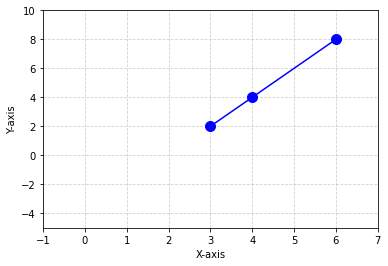

In [5]:
plt.plot(x_i, y_i, 'b-o', markersize=10, label='Two Points')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.xlim([-1, 7])
plt.ylim([-5, 10])
plt.grid(True, linestyle='--', alpha=0.6)

## Multiple features on Linear Regression

Let´s see how the linear regression behaves when more than one feature. Next you will find some data about the prices of housing in Canada. The features to make the analysis are the number of rooms and the year of construction: Remember the formula would contemplate more than one beta:  
 **Y = a + b0.x0 + b1.x1**

| index     | no_rooms              | year | value |
|:-------:|:-----------------:|:----:|:----------:|  
| 1  | 3         | 2015 |    0,8     |   
| 2  | 5  | 2023 |    1,6     |   
 

In [6]:
import pandas as pd
from typing import List 

data ={"no_rooms":[3,5],"year":[2015,2023],"value":[0.8,1.6]}
house_pricing= pd.DataFrame(data)


def beta_multiple_points(
    df: pd.DataFrame, 
    target_col: str
) -> List[float]:

    delta_target = df.iloc[1][target_col] - df.iloc[0][target_col]
    feature_cols = [col for col in df.columns if col != target_col]
    betas= []
    
    for feature in feature_cols:
        delta_feature = df.iloc[1][feature] - df.iloc[0][feature]
        betas.append(delta_target / delta_feature)
    return betas
        

betas= beta_multiple_points(house_pricing,"value")
betas

[0.4, 0.1]

**Interpretation:**  

- For each additional room, the house value increases by 40% (\$400.00).  
- For each additional year, the house value increases by 10% (\$100.00).


And now to calculate alpha, we need to re adjust the formula for the additional features   **a = Y - b0.x0 - b1.x1**

In [7]:
def alpha_multiple_points(df: pd.DataFrame ,target_col: str, b:List[float])-> float:
    Y_0 = df.iloc[0][target_col]
    feature_cols = [col for col in df.columns if col != target_col]
    sum_of_beta_product_x = 0
    
    for feature, beta in zip(feature_cols, b):
        X_0 = df.iloc[0][feature]  
        sum_of_beta_product_x += beta * X_0
    alpha = Y_0 - sum_of_beta_product_x
    return alpha

new_a= alpha_multiple_points(house_pricing,"value",betas)
new_a

-201.89999999999998

Now that we have beta and alpha, let´s use them to predict the value of a house with 4 rooms and built in 2021 :  

In [8]:
def predict_linear_regression_two_points(
    df: pd.DataFrame, 
    target_col: str,
    a: float,
    b:List[float],
    new_X_values: List[float]
) -> float:
    feature_cols = [col for col in df.columns if col != target_col]
    sum_of_beta_product_x = 0
    
    for x, beta in zip(new_X_values, b):
        sum_of_beta_product_x += beta * x
    Y_pred = a + sum_of_beta_product_x  
    return Y_pred

Y_pred = predict_linear_regression_two_points(house_pricing,"value",new_a,betas,[4,2021])
Y_pred

1.8000000000000398

 A house in Canada with 4 rooms and built in 2021 would cost \$ 1.8 million dollars

## Linear Regression with multiple records

Let´s assume that you believe that having multiple friends causes people to spend more time in a website. So you are in charge of building a model describing this relationship.  Since you found a strong linear relationship, we can start building a linear model.  
<br>**Yi = a + bXi**
<br>  
Yi is the number of minutes each user i spends on the site daily  
Xi is the number of friends each user i has  

Let´s remember first some statistic concepts:

| Function           | Statistical Concept    | Logic                                                                                                                                         |
|--------------------|------------------------|----------------------------------------------------------------------------------------------------------------------------------------------|
| mean               | Mean (xˉ)              | The sum of values divided by the number of values.                                                                                            |
| de_mean            | Deviation from Mean    | Calculates xᵢ − xˉ for every data point. This is the first step for calculating variance and covariance.                                      |
| variance           | Variance (s²)          | The average of the squared deviations from the mean (using n − 1 in the denominator for an unbiased estimate of the population variance).     |
| standard_deviation | Standard Deviation (s) | The square root of the variance.                                                                                                              |
| correlation        | Correlation (r)        | Measures the strength and direction of a linear relationship, standardizing the covariance by dividing by the product of the standard deviations. |
| least_squares_fit  | Regression Coefficients | Combines all the above to find the optimal slope (β) and intercept (α) for the line of best fit.                                              |


The sample correlation coefficient is defined as:

$$
r_{xy} = 
\frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2 \; \sum_{i=1}^{n} (y_i - \bar{y})^2}}
$$


In [ ]:
import os
import urllib.request

BASE = "https://raw.githubusercontent.com/cienciadadesdsuab/DS26-27/main/Laboratoris/03_Linear%20Regression/"
os.makedirs("scratch", exist_ok=True)
for f in ["r.jpg", "scratch/linear_algebra.py", "scratch/statistics.py"]:
    urllib.request.urlretrieve(BASE + f, f)

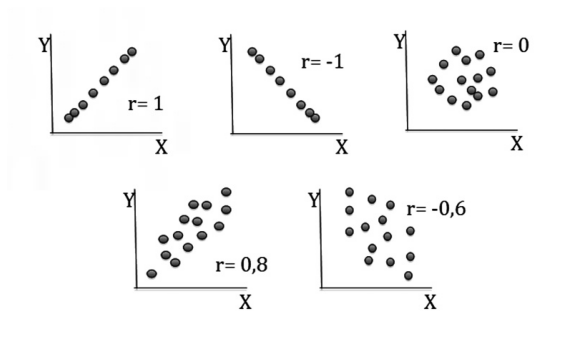

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
imagen = mpimg.imread('r.jpg')
plt.figure(figsize=(10, 8))
plt.imshow(imagen)
plt.axis('off')
plt.show()

In [10]:
def predict (alpha: float, beta:float,x_i:list)-> list:
    return alpha+ beta*x_i

But how do we chose alpha and beta ? Since we know the actual output y_i, we can compute the error for each pair:

In [11]:
def error (alpha: float, beta:float,x_i:list , y_i: float)-> float:
    return predict(alpha,beta,x_i) - y_i

But what we actually want to know is the total error over the entire dataset. But we can just add the errors  - If the prediction for x_1 is too high and the prediction for x_2 is too low, the errors may just cancel out. So instead we add up the sqaured errors:

In [12]:
from scratch.linear_algebra import Vector

def sum_of_sqerror (alpha: float, beta:float,x: Vector, y: Vector)-> float:
    return sum(error(alpha,beta,x_i,y_i)**2 for x_i,y_i in zip(x,y))

The least squares solution is to choose the alpha and betha that makes the sum_of_sqerror as small as possible: 

In [15]:
from typing import Tuple
from scratch.statistics import correlation, standard_deviation, mean

def least_squares_fit (x: Vector, y: Vector)-> Tuple[float, float]:
    beta= correlation(x,y)*standard_deviation(y)/standard_deviation(x)
    alpha = mean(y) -beta*mean(x)
    return alpha,beta

The choice of **alpha** simply says that when we see the average value of the independant variable X, we predict the average value of Y   
The choice of **Beta** means that when the input value increases by standard deviation X, the prediction increases by correlation (X,Y) * standard deviation Y. In the case where X and Y are perfectly correlated, a one standard deviation increase in X results in a one standard deviation increase of Y in the prediction. And when the correlation is 0, beta is also 0, which means that changes in X don´t affect the prediction at all. 

In [16]:
from scratch.statistics import num_friends_good, daily_minutes_good

alpha, beta = least_squares_fit(num_friends_good,daily_minutes_good)
alpha,beta

(22.94755241346903, 0.903865945605865)

This gives values of alpha = 22.95 and beta =0.903. So our model says that we expect an user with n friends to spend 22.95 + nx0.903 minutes on the site each day . That is, we predict that a user with no friends on DataSciencester would still spend about 23 minutes a day on the site. And for each additional friend, we expect a user to spend almost a minute more on the site each day.

In [25]:
r= correlation(num_friends_good,daily_minutes_good)
r

0.5736792115665573

The correlation of 0.57  between # of friends and daily minutes is positive but sort of weak

In [24]:
r_squared=r**2
r_squared

0.32910783778362684

Only **33 %** of the variation in daily minutes is explained by the number of friends

In [18]:
error= sum_of_sqerror(alpha, beta,num_friends_good,daily_minutes_good)
MSE= error/len(num_friends_good)
MSE

65.00797683198606

An MSE of **65** indicates that, by squaring the errors and averaging them, the “size of the error” is relatively large.

In [19]:
import math
RMSE = math.sqrt(MSE)
RMSE

8.062752435241086

The linear regression model fails aprox in **8**  minutes per prediction. This will be big of small depending of the mean of daily_minutes_good

In [20]:
y_avr= mean(daily_minutes_good)
y_avr

29.16330049261084

## Linear Regression with sklearn

In [21]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array(num_friends_good).reshape(-1, 1)  # <-- reshape here
y = np.array(daily_minutes_good)  # y can stay 1D

reg = LinearRegression().fit(X, y)

print('The estimated value of alpha (the intercept of the line) is:', reg.intercept_)
print('The estimated value of beta (the slope of the line) is:', reg.coef_[0])




The estimated value of alpha (the intercept of the line) is: 22.947552413468976
The estimated value of beta (the slope of the line) is: 0.9038659456058723


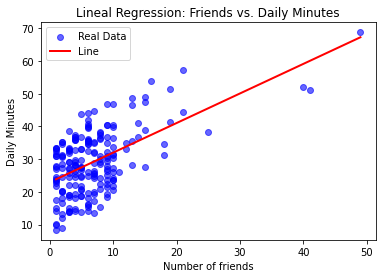

In [22]:
y_pred = reg.predict(X)

plt.scatter(X, y, color="blue", alpha=0.6, label="Real Data")   # puntos originales
plt.plot(X, y_pred, color="red", linewidth=2, label="Line")  # línea de regresión

plt.xlabel("Number of friends")
plt.ylabel("Daily Minutes")
plt.title("Lineal Regression: Friends vs. Daily Minutes")
plt.legend()
plt.show()


$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$ 

$ 
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$

$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$


In [23]:

from sklearn.metrics import r2_score, mean_squared_error
y_pred = reg.predict(X)


r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)


print("R^2:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

R^2: 0.32910783778362984
MSE: 65.0079768319861
RMSE: 8.062752435241089


# 📘 Exercise: Building and Analyzing a Linear Regression Model

## 1. Dataset

Use the following small dataset of students’ **study hours per week** and their **exam scores**:

| Study Hours | Exam Score |
|-------------|------------|
| 2           | 65         |
| 3           | 67         |
| 5           | 75         |
| 7           | 78         |
| 8           | 85         |
| 10          | 89         |
| 12          | 93         |

---

## 2. Tasks

1. **Plot the data** (scatterplot) to see the relationship between study hours and exam scores.  

2. **Fit a linear regression model** predicting `Exam Score` from `Study Hours`.  
   - You may use Python (`sklearn.linear_model.LinearRegression`) or another tool.  

3. **Find the regression equation** (slope and intercept).  
   - Write it in the form:  
     \[
     \hat{y} = a + b \cdot x
     \]  

4. **Interpret the slope** in words.  
   - What does it mean in this context?  

5. **Make a prediction**:  
   - Predict the exam score for a student who studies **9 hours per week**.  

6. **Evaluate the model**:  
   - Report the \( R^2 \) value.  
   - Explain whether the model seems to fit the data well.  
